# Problema 2 - Classificação Multiclasse: Categoria de Poluição por SO2
O dióxido de enxofre (SO2) é um poluente atmosférico originado principalmente pela queima de combustíveis fósseis e por atividades industriais. Quando depositado sobre superfícies metálicas, o SO2 acelera a corrosão dos metais, visto que reage com a umidade e forma ácido sulfúrico (H2SO4).

A norma ISO 9223 classifica o nível de poluição atmosférica por SO2 em quatro categorias, denominadas **classes de poluição (P)**, na unidade de medida mg/m2/dia:
- **P0**: Pd <= 4, atmosfera rural
- **P1**: 4 < Pd <= 24, atmosfera urbana
- **P2**: 24 < Pd <= 80, atmosfera industrial
- **P3**: 80 < Pd <= 200, atmosfera industrial altamente poluída

O objetivo é **classificar o nível de poluição de uma estação** a partir de variáveis ambientais, geográficas e socioeconômicas.

### Conjunto de Dados
O dataset "dataset_SO2.xlsx" agrupa as medições de deposição de SO2 coletadas em estações de vários países. As variáveis de entrada utilizadas são:

- **weight_urbanization_20.0km**: Peso de urbanização em um raio de 20 km 
- **distance_to_industry_20.0km**: Distância à indústria mais próxima (em km) 
- **weigthed_industry_20.0km**: Peso de atividade industrial em um raio de 20 km 
- **edgar_so2_emission**: Emissão de SO2 estimada (projeto EDGAR) 
- **merra2_so2mass**: Massa de SO2 na atmosfera (dados de reanálise atmosférica do MERRA-2) 
- **hdr_co2_prod**: Emissão de CO₂ per capita (pelo projeto HDR das Nações Unidas) 
- **hdr_hdi**: Índice de Desenvolvimento Humano (pelo projeto HDR das Nações Unidas)
- **era5_relative_humidity**: Umidade relativa média (dados de reanálise atmosférica do ERA5) 
- **era5_temperature**: Temperatura média (dados de reanálise atmosférica do ERA5) 
- **roughness_mean**: Rugosidade média do terreno 

## Estratégia de Split
Os dados do projeto "africa_saaqis_2025" são reservados para teste.

## Modelos Comparados
- **MLP (nossa biblioteca)**: Rede neural implementada do zero 
- **MLPClassifier (sklearn)**: Rede neural da biblioteca sklearn 
- **Random Forest**: Ensemble de árvores de decisão 
- **KNN**: K-Nearest Neighbors 

In [1]:
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('../')
import NNRaw.neural_network as NN

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carregamento do dataset

In [2]:
df = pd.read_excel('../datasets/dataset_SO2.xlsx')
print(f'Shape: {df.shape}')
df.head()

Shape: (1815, 14)


,project_name,station_id,start_date,weight_urbanization_20.0km,distance_to_industry_20.0km,weigthed_industry_20.0km,edgar_so2_emission,merra2_so2mass,hdr_co2_prod,hdr_hdi,era5_relative_humidity,era5_temperature,roughness_mean,so2
0,international_isocorrag_2010,14,1984-10-04,1085.992152,0.642491,3.999055e+06,2557.159912,8.470943e+09,3.434042,0.724,74.508237,16.898555,0.100000,10.00
1,international_isocorrag_2010,17,1986-10-07,675.628484,0.378722,2.115519e+07,897.700989,1.382508e+10,16.578071,0.861,68.620304,6.759757,0.219097,11.28
2,international_isocorrag_2010,18,1986-09-08,6.835845,0.185508,2.470811e+05,124.359001,2.075002e+10,15.944796,0.748,80.891606,5.744208,0.261929,20.24
3,international_isocorrag_2010,19,1986-09-30,278.608866,0.397439,5.795232e+06,1318.640015,3.961262e+10,15.944796,0.748,76.167034,7.663679,0.219090,71.60
4,international_isocorrag_2010,48,1986-11-04,542.950287,0.225268,3.224362e+06,10767.000000,1.253642e+10,11.413714,0.811,80.457840,2.532528,0.400000,17.12


In [3]:
def stratify_so2(x):
    """Classifica so2 em categorias de poluição conforme ISO 9223."""
    if x <= 4:
        return 'P0'
    elif x <= 24:
        return 'P1'
    elif x <= 80:
        return 'P2'
    else:
        return 'P3'

df['pollution_class'] = df['so2'].apply(stratify_so2)

print('Distribuição das classes de poluição:')
print(df['pollution_class'].value_counts().sort_index())

Distribuição das classes de poluição:
pollution_class
P0     489
P1    1170
P2     156
Name: count, dtype: int64


In [4]:
X_cols = [
    'weight_urbanization_20.0km',
    'distance_to_industry_20.0km',
    'weigthed_industry_20.0km',
    'edgar_so2_emission',
    'merra2_so2mass',
    'hdr_co2_prod',
    'hdr_hdi',
    'era5_relative_humidity',
    'era5_temperature',
    'roughness_mean'
]
y_col = 'so2'

## 3. Pré-processamento

Para a nossa MLP com softmax + cross-entropy categórica, o target precisa estar em formato **one-hot**. Para os modelos sklearn, usamos o label inteiro (0, 1, 2, 3).

In [5]:
df_train = df[df['project_name'] != 'africa_saaqis_2025'].copy()
df_test  = df[df['project_name'] == 'africa_saaqis_2025'].copy()

print(f'Treino: {len(df_train)} amostras')
print(f'Teste: {len(df_test)} amostras')
print(f'Projetos no teste: {df_test["project_name"].unique()}')

Treino: 869 amostras
Teste: 946 amostras
Projetos no teste: ['africa_saaqis_2025']


In [6]:
CLASS_ORDER = ['P0', 'P1', 'P2', 'P3']
class_to_int = {c: i for i, c in enumerate(CLASS_ORDER)}
N_CLASSES = len(CLASS_ORDER)

y_train_int = df_train['pollution_class'].map(class_to_int).to_numpy()
y_test_int  = df_test['pollution_class'].map(class_to_int).to_numpy()

# One-hot para a nossa MLP
y_train_oh = np.eye(N_CLASSES)[y_train_int]

# Normalização das variáveis de entrada
scaler = MinMaxScaler()
X_train_raw = df_train[X_cols].to_numpy()
X_test_raw  = df_test[X_cols].to_numpy()
X_train_sc  = scaler.fit_transform(X_train_raw)
X_test_sc   = scaler.transform(X_test_raw)

stratify_train = df_train['pollution_class']

print('Pré-processamento concluído')
print(f'y_train_oh shape: {y_train_oh.shape}')

Pré-processamento concluído
y_train_oh shape: (869, 4)


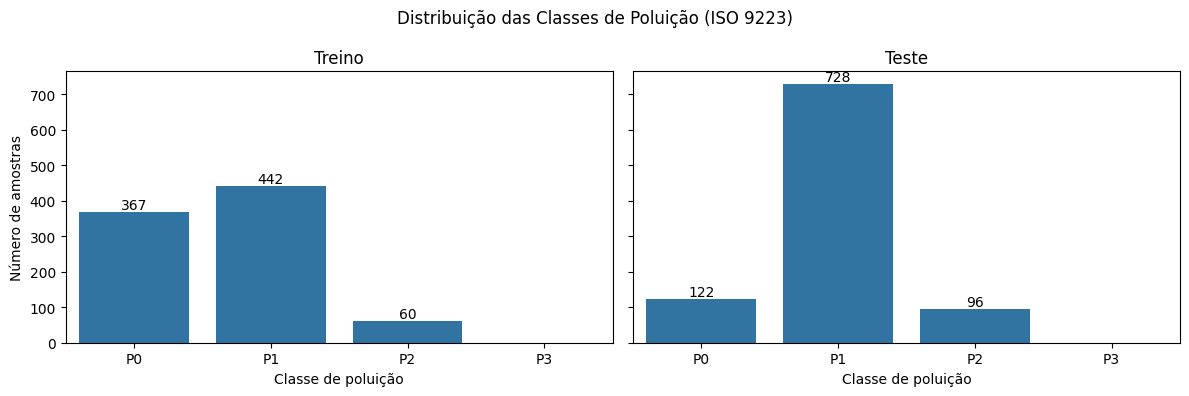

In [7]:
# Distribuição das classes de poluição no treino e teste
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)

sns.countplot(
    x='pollution_class',
    data=df_train.sort_values('pollution_class'),
    order=['P0','P1','P2','P3'],
    ax=axes[0]
)

axes[0].set_title('Treino')
axes[0].set_xlabel('Classe de poluição')
axes[0].set_ylabel('Número de amostras')
axes[0].bar_label(axes[0].containers[0])


sns.countplot(
    x='pollution_class',
    data=df_test.sort_values('pollution_class'),
    order=['P0','P1','P2','P3'],
    ax=axes[1]
)

axes[1].set_title('Teste')
axes[1].set_xlabel('Classe de poluição')
axes[1].set_ylabel('')
axes[1].bar_label(axes[1].containers[0])

plt.suptitle('Distribuição das Classes de Poluição (ISO 9223)')
plt.tight_layout()
plt.show()

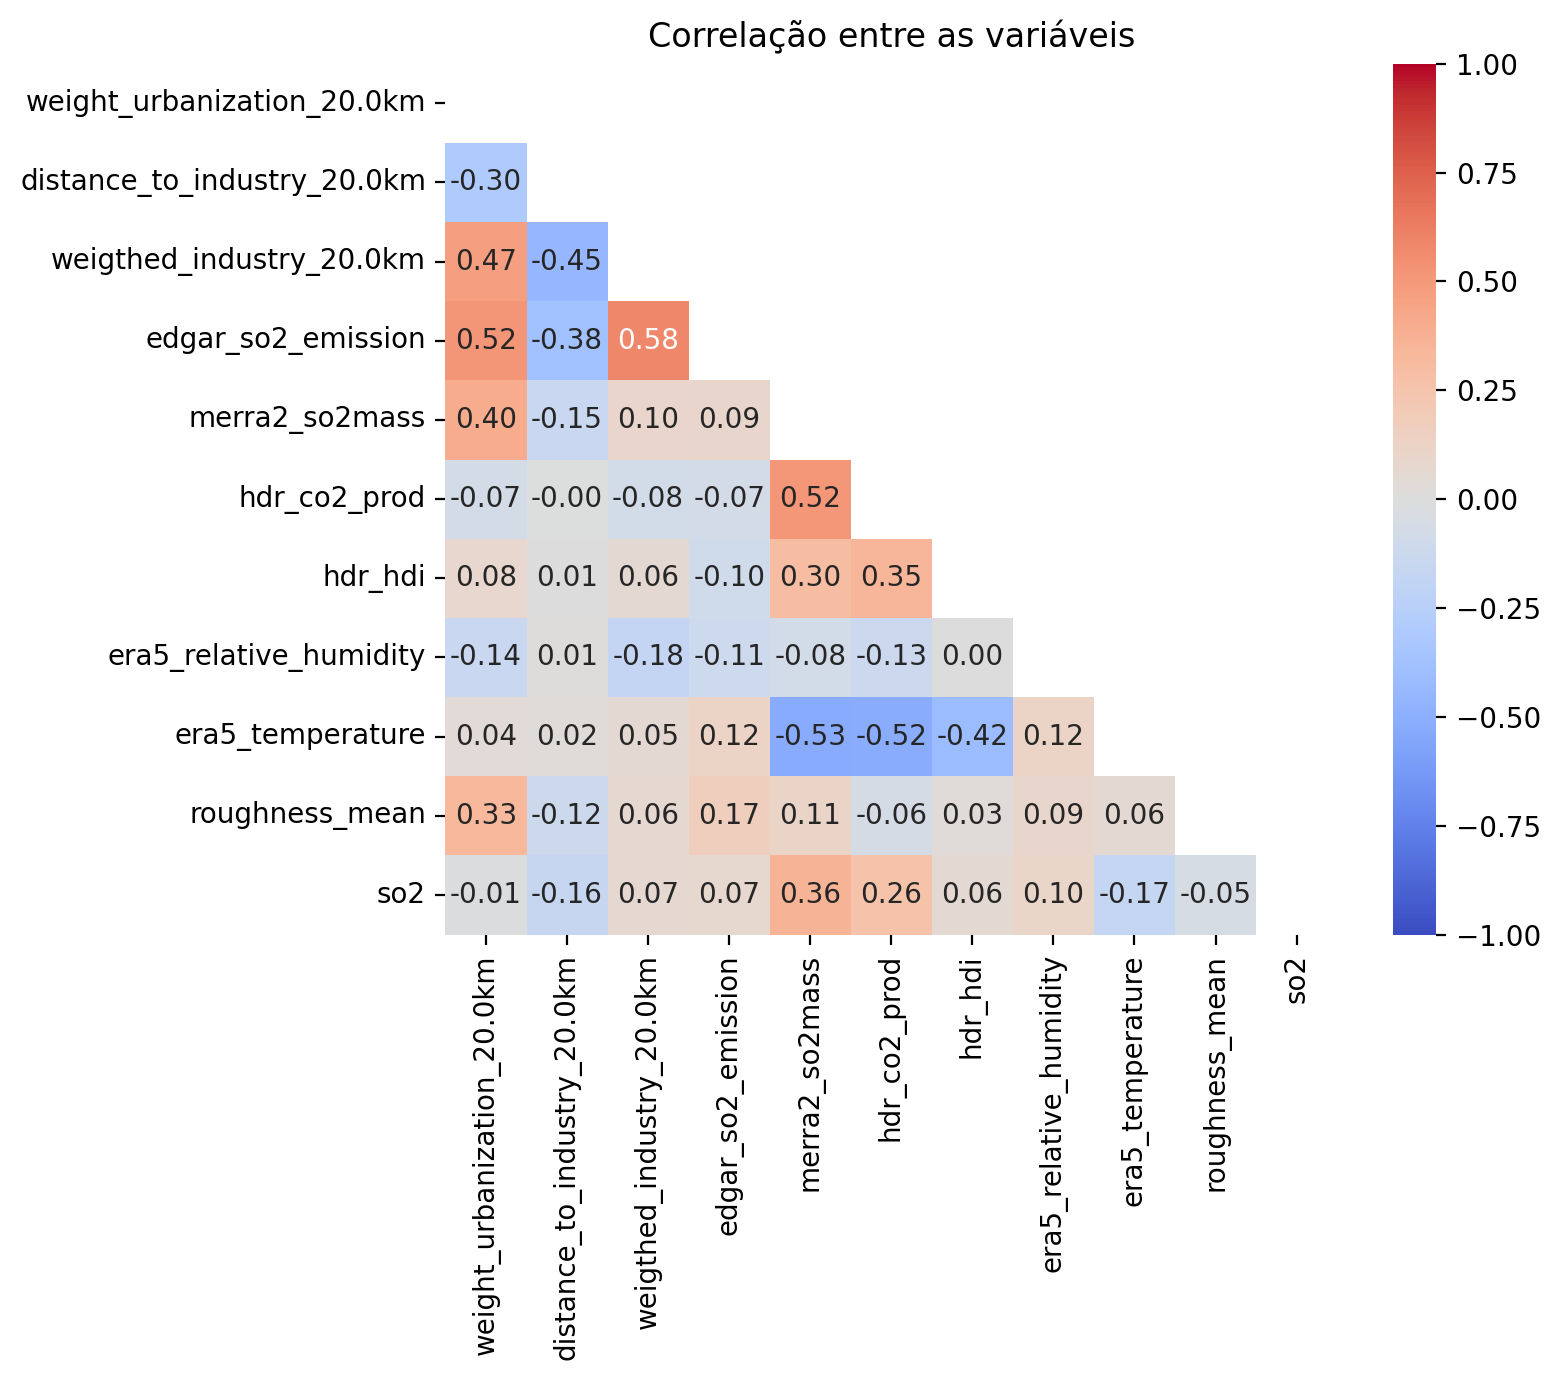

In [8]:
# Matriz de Correlação 
corr_train = df_train[X_cols + [y_col]].corr(method='spearman')

mask = np.triu(np.ones_like(corr_train, dtype=bool))

plt.figure(figsize=(8,7), dpi=200)

sns.heatmap(
    corr_train,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlação entre as variáveis")
plt.tight_layout()
plt.show()

## 4. Cross Validation e avaliação dos modelos sklearn
Usamos **Random Subsampling Estratificado** (Monte Carlo CV): 100 splits de 70%/30% mantendo a proporção das classes de poluição. As métricas são a média dos 100 splits.

In [9]:
cv = StratifiedShuffleSplit(n_splits=100, train_size=0.7, random_state=RANDOM_STATE)

def evaluate_classifier(model, X, y, stratify):
    """Avalia um classificador sklearn com Monte Carlo CV estratificado."""
    acc_list, f1_list = [], []

    X_df = pd.DataFrame(X)
    y_s  = pd.Series(y)
    strat_s = pd.Series(stratify.values)

    for tr_idx, val_idx in cv.split(X_df, strat_s):
        X_tr, X_val = X_df.iloc[tr_idx].values, X_df.iloc[val_idx].values
        y_tr, y_val = y_s.iloc[tr_idx].values, y_s.iloc[val_idx].values

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        acc_list.append(accuracy_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred, average='macro', zero_division=0))

    return {
        'Acurácia': np.mean(acc_list),
        'F1-macro': np.mean(f1_list)
    }

def evaluate_mlp_classifier(X, y_onehot, y_int, stratify):

    acc_list = []
    f1_list = []

    X_df = pd.DataFrame(X)
    y_df = pd.DataFrame(y_onehot)
    strat_s = pd.Series(stratify.values)

    for tr_idx, val_idx in cv.split(X_df, strat_s):

        X_tr = X_df.iloc[tr_idx].values
        X_val = X_df.iloc[val_idx].values

        y_tr = y_df.iloc[tr_idx].values

        y_val = y_int[val_idx]

        scaler = MinMaxScaler()

        X_tr_sc = scaler.fit_transform(X_tr)
        X_val_sc = scaler.transform(X_val)

        rede = NN.RedeNeural(perda='cross_entropy_categorica')

        rede.adicionar_camada(10,32,'relu','he')
        rede.adicionar_camada(32,16,'relu','he')
        rede.adicionar_camada(16,4,'softmax','xavier')

        rede.treinar(
            X_tr_sc,
            y_tr,
            epocas=1000,
            taxa_aprendizado=0.005,
            tamanho_batch=32,
            verbose=False
        )

        probs = rede.prever(X_val_sc)

        y_pred = np.argmax(probs, axis=1)

        acc_list.append(
            accuracy_score(y_val, y_pred)
        )

        f1_list.append(
            f1_score(
                y_val,
                y_pred,
                average='macro',
                zero_division=0
            )
        )

    return {
        "Acurácia": np.mean(acc_list),
        "F1-macro": np.mean(f1_list)
    }

In [10]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=15,
    min_samples_leaf=2, random_state=RANDOM_STATE
)

knn = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=7))
])

mlp_sk = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

sklearn_models = {
    'Random Forest': rf,
    'KNN': knn,
    'MLPClassifier (sklearn)': mlp_sk
}

In [11]:
resultados_cv = {}
tempos_treino = {}

for nome, modelo in sklearn_models.items():
    print(f'\n Avaliando {nome}')
    t0 = time.time()

    resultados_cv[nome] = evaluate_classifier(
        modelo,
        X_train_raw,
        y_train_int,
        stratify_train
    )

    tempos_treino[nome] = time.time()-t0

    print(f'Acurácia: {resultados_cv[nome]["Acurácia"]:.4f}')
    print(f'F1 Macro: {resultados_cv[nome]["F1-macro"]:.4f}')
    print(f'Tempo: {tempos_treino[nome]:.2f}s')



print('\n Avaliando MLP (nossa biblioteca)')
t0 = time.time()

resultados_cv["MLP (nossa biblioteca)"] = evaluate_mlp_classifier(
    X_train_raw,
    y_train_oh,
    y_train_int,
    stratify_train
)

tempos_treino["MLP (nossa biblioteca)"] = time.time()-t0

print(f'Acurácia: {resultados_cv["MLP (nossa biblioteca)"]["Acurácia"]:.4f}')
print(f'F1 Macro: {resultados_cv["MLP (nossa biblioteca)"]["F1-macro"]:.4f}')
print(f'Tempo: {tempos_treino["MLP (nossa biblioteca)"]:.2f}s')


 Avaliando Random Forest
Acurácia: 0.7923
F1 Macro: 0.7523
Tempo: 114.60s

 Avaliando KNN
Acurácia: 0.6875
F1 Macro: 0.6100
Tempo: 1.42s

 Avaliando MLPClassifier (sklearn)
Acurácia: 0.6415
F1 Macro: 0.5372
Tempo: 139.01s

 Avaliando MLP (nossa biblioteca)
Acurácia: 0.6341
F1 Macro: 0.5434
Tempo: 476.44s


## 5. Treinamento final dos modelos com todos os dados de treino

In [12]:
rf.fit(X_train_raw, y_train_int)
knn.fit(X_train_raw, y_train_int)
mlp_sk.fit(X_train_raw, y_train_int)

rede = NN.RedeNeural(perda='cross_entropy_categorica')
rede.adicionar_camada(10,32,'elu','he')
rede.adicionar_camada(32,16,'elu','he')
rede.adicionar_camada(16,4,'softmax','xavier')

t0 = time.time()

rede.treinar(
    X_train_sc,
    y_train_oh,
    epocas=1000,
    taxa_aprendizado=0.005,
    tamanho_batch=32,
    verbose=True
)

tempo_final = time.time()-t0

Época     1/1000 | Perda treino: 1.068643
Época   100/1000 | Perda treino: 0.818535
Época   200/1000 | Perda treino: 0.769002
Época   300/1000 | Perda treino: 0.729588
Época   400/1000 | Perda treino: 0.712262
Época   500/1000 | Perda treino: 0.706026
Época   600/1000 | Perda treino: 0.694647
Época   700/1000 | Perda treino: 0.670223
Época   800/1000 | Perda treino: 0.669533
Época   900/1000 | Perda treino: 0.661754
Época  1000/1000 | Perda treino: 0.656594


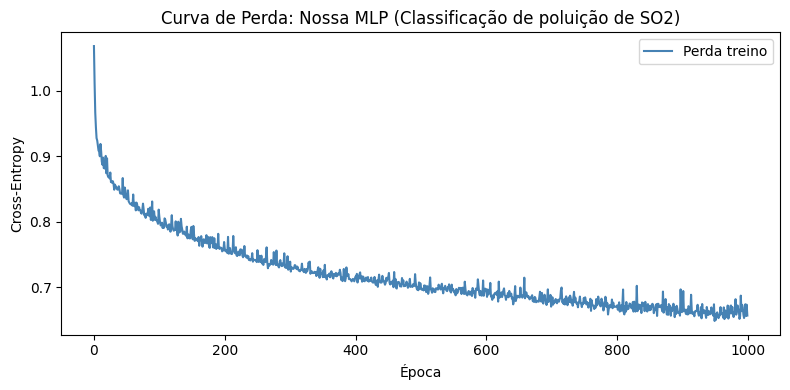

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(rede.historico['perda_treino'], label='Perda treino', color='steelblue')
plt.xlabel('Época')
plt.ylabel('Cross-Entropy')
plt.title('Curva de Perda: Nossa MLP (Classificação de poluição de SO2)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
preds_train = {
    "Random Forest":rf.predict(X_train_raw),
    "KNN":knn.predict(X_train_raw),
    "MLPClassifier (sklearn)":mlp_sk.predict(X_train_raw),
    "MLP (nossa biblioteca)":np.argmax(rede.prever(X_train_sc),axis=1)
}

In [15]:
resultados_treino = {}

for nome, pred in preds_train.items():
    resultados_treino[nome] = {
        "Acurácia":accuracy_score(y_train_int,pred),

        "F1-macro":f1_score(y_train_int,pred,average="macro",zero_division=0)
    }

df_treino = (pd.DataFrame(resultados_treino).T.round(4))
print("Resultados no conjunto de treino")
display(df_treino.sort_values("F1-macro",ascending=False))

Resultados no conjunto de treino


,Acurácia,F1-macro
Random Forest,0.9678,0.9442
KNN,0.8113,0.7928
MLPClassifier (sklearn),0.7779,0.7155
MLP (nossa biblioteca),0.6617,0.5869


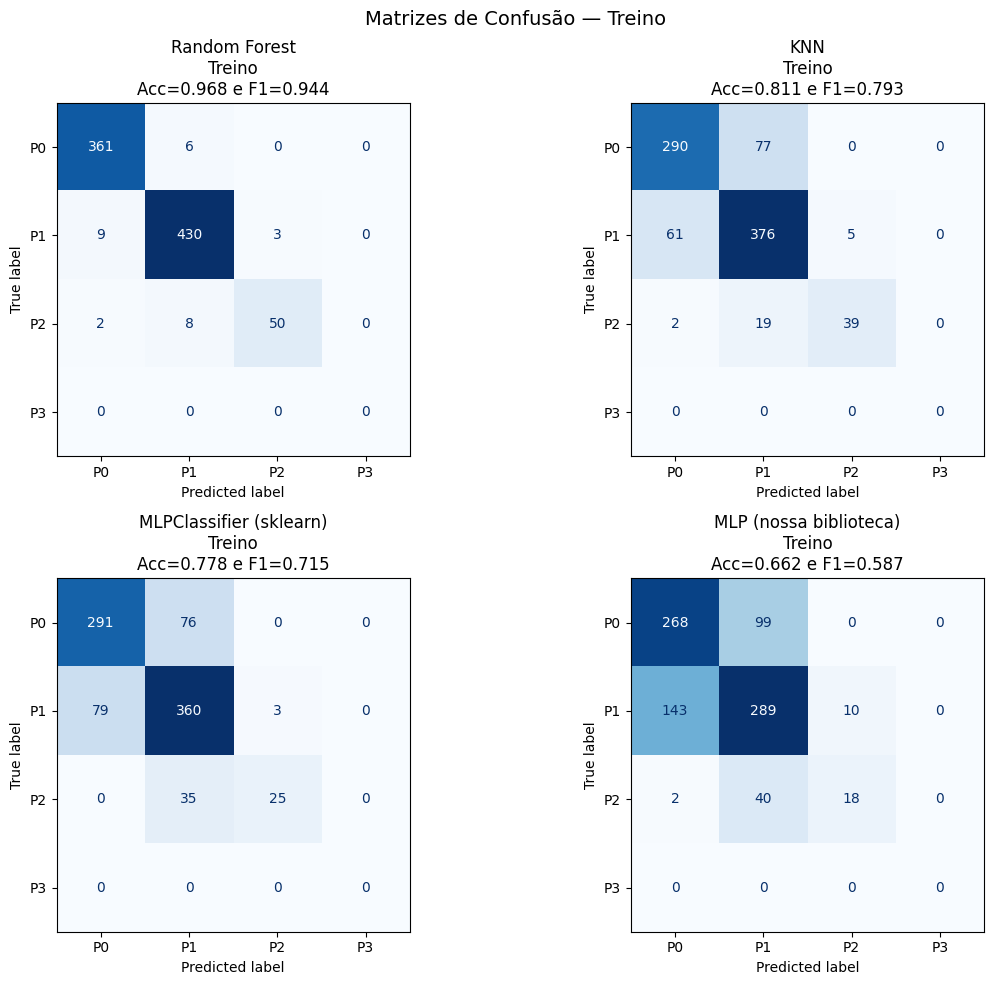

In [16]:
fig, axes = plt.subplots(2,2,figsize=(12,10))
axes = axes.ravel()
for ax, (nome, pred) in zip(axes, preds_train.items()):
    cm = confusion_matrix(y_train_int,pred,labels=[0,1,2,3])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_ORDER
    )

    disp.plot(ax=ax,colorbar=False,cmap="Blues")
    acc = accuracy_score(y_train_int,pred)
    f1 = f1_score(y_train_int,pred,average="macro",zero_division=0)
    ax.set_title(f"{nome}\nTreino\n" f"Acc={acc:.3f} e " f"F1={f1:.3f}")

plt.suptitle("Matrizes de Confusão — Treino",fontsize=14)
plt.tight_layout()
plt.show()

## 6. Predição no conjunto de teste

In [17]:
preds = {
    "Random Forest":rf.predict(X_test_raw),
    "KNN":knn.predict(X_test_raw),
    "MLPClassifier (sklearn)":mlp_sk.predict(X_test_raw),
    "MLP (nossa biblioteca)":np.argmax(rede.prever(X_test_sc),axis=1)
}

In [18]:
resultados_teste = {}

for nome, pred in preds.items():
    resultados_teste[nome] = {
        "Acurácia":accuracy_score(y_test_int,pred),
        "F1-macro":f1_score(y_test_int,pred,average="macro",zero_division=0)
    }

In [19]:
df_teste = pd.DataFrame(resultados_teste).T.round(4)
print("\nResultados no conjunto de teste")
display(df_teste.sort_values("F1-macro",ascending=False))


Resultados no conjunto de teste


,Acurácia,F1-macro
MLP (nossa biblioteca),0.6681,0.4210
MLPClassifier (sklearn),0.6903,0.3997
Random Forest,0.7326,0.3437
KNN,0.6617,0.3163


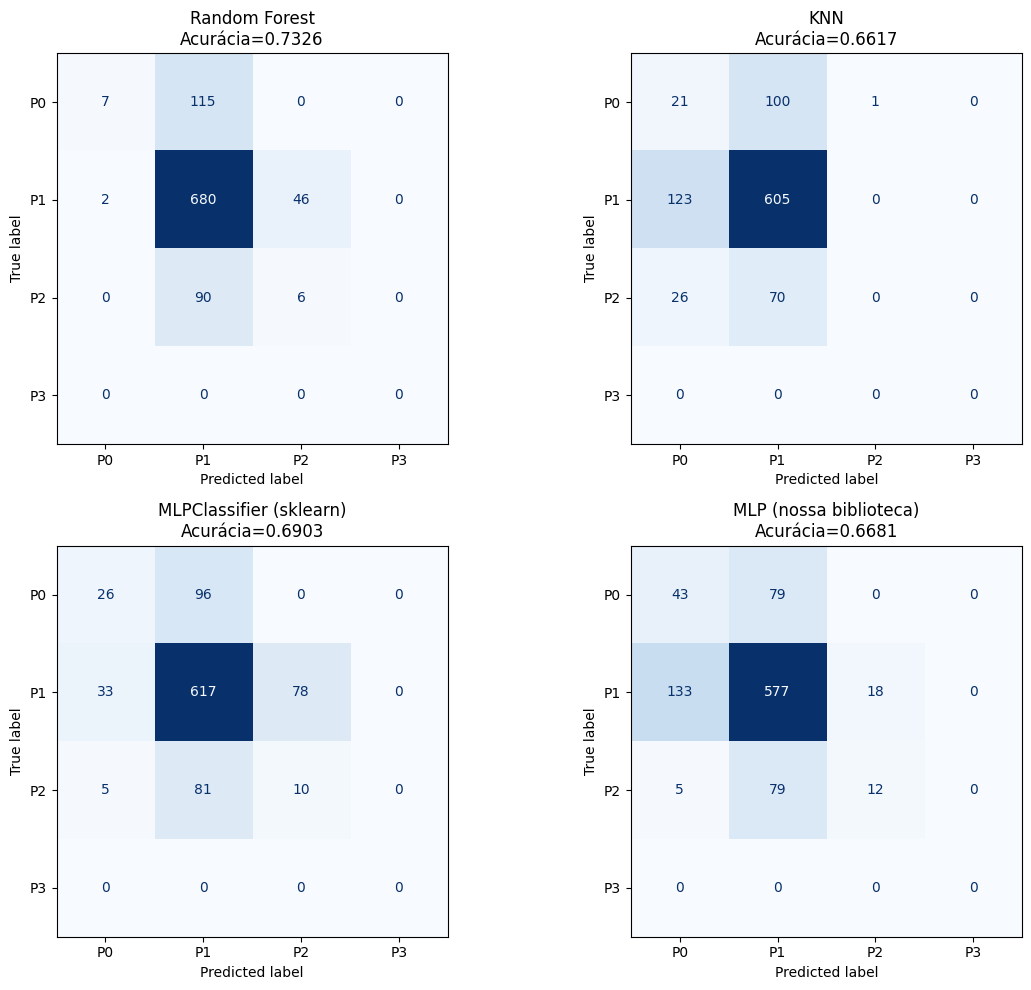

In [20]:
fig, axes = plt.subplots(2,2,figsize=(12,10))
axes = axes.ravel()
for ax, (nome, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test_int,pred,labels=[0,1,2,3])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_ORDER
    )
    disp.plot(ax=ax,colorbar=False,cmap="Blues")
    acc = accuracy_score(y_test_int,pred)
    ax.set_title(f"{nome}\nAcurácia={acc:.4f}")

plt.tight_layout()
plt.show()